____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2501000', 'swot2502000', 'swot2503000', 'swot2504000', 'swot2505000', 'swot2506000', 'swot2507000', 'swot2508000', 'swot2509000', 'swot25010000', 'swot25011000', 'swot25012000', 'swot25013000', 'swot25014000', 'swot2kmnaive', 'swot2km1000', 'swot2km2000', 'swot2km3000', 'swot2km4000', 'swot2km5000', 'swot2km6000', 'swot2km7000', 'swot2km8000', 'swot2km9000', 'swot2km10000', 'swot2km11000', 'swot2km12000', 'swot2km13000', 'swot2km14000', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', spectral_key = '', wd_key = 'era5', ggd_var='etac', wd_depth='0', wd_model='rio'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', spectral_key = '', wd_key = 'era5', ggd_var='etac', wd_depth='15', wd_model='rio')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_numser')

DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])

nofilter___swot2kmnaive_etac__rio_0era5
nofilter___swot2kmnaive_etac__rio_15era5
Identified SWOT and drifter outliers have been removed


In [4]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

DSSr = DSr.where(DSr.depth==0, drop=True).isel(id_comb=[0])
DSDr = DSr.where(DSr.depth==15, drop=True).isel(id_comb=[1])

# For surface + 15m
DSr = xr.concat([DSSr.isel(id_comb=0), DSDr.isel(id_comb=0)], dim='row_numser')

In [5]:
dfr = DSr.to_dataframe().reset_index().set_index('row_numser')
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_numser')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])

dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert', 'distance_to_coast']], dfr], axis=1).dropna()


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16671/590981581.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])


_________
# Dependency on the cross_track distance

In [7]:
compute_error = 'centrallimit'
dfct = dfrr[dfrr.swh_model<2]
ct_dist_bins = np.arange(0, 70000, 1000)
dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
dsc = compute_mean_square_groupby(dfct, groupby = 'abs_cross_track_distance_cut', dirname = ('x', 'y'), compute_error=compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd']  )
dsc['meanbin_swh_model'] = dfct.groupby('abs_cross_track_distance_cut', observed=False).swh_model.mean().dropna().to_xarray()
dsc = dsc.where(dsc.nb_coloc>100)
dsc['abs_cross_track_distance_cut'] = dsc['abs_cross_track_distance_cut']/1000

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16671/2810217899.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)


[ 3.12472839e-03 -1.82663767e-01  5.83921403e+00]


(8.0, 62.0)

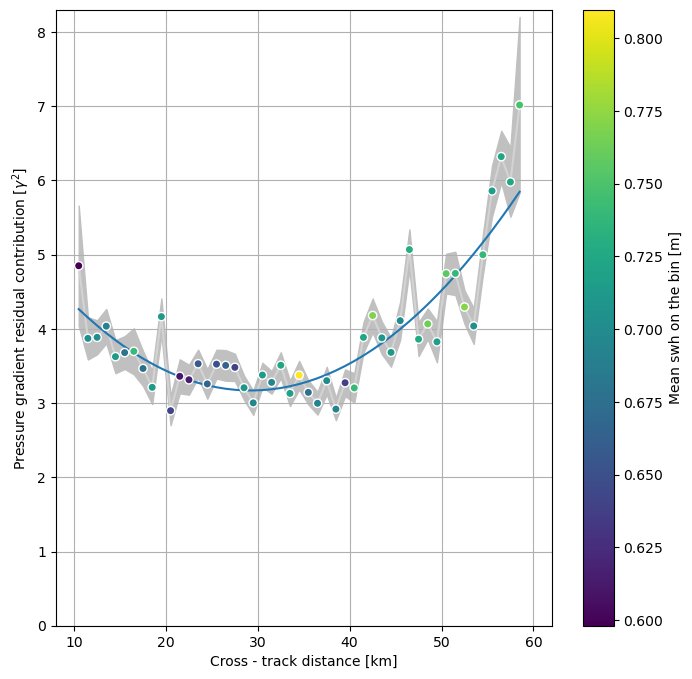

In [20]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
dsc['ser__E_ggd'] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
#dsc.Ex_ggd.plot(ax=ax, marker='+')
#dsc.Ey_ggd.plot(ax=ax, marker='+')
dsc.E_ggd.plot(ax=ax, marker='+', c='lightgrey')
plot_error(dsc, 'abs_cross_track_distance_cut', 'E_ggd', ax=ax, suf='ser__')
sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
plt.colorbar(sc, label ='Mean swh on the bin [m]')

c = dsc.abs_cross_track_distance_cut
coef = np.polyfit(c, dsc.E_ggd,2,w =dsc.nb_coloc)
ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2])
print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')
ax.set_ylim(0, 8.3)
ax.set_xlim(8,62)

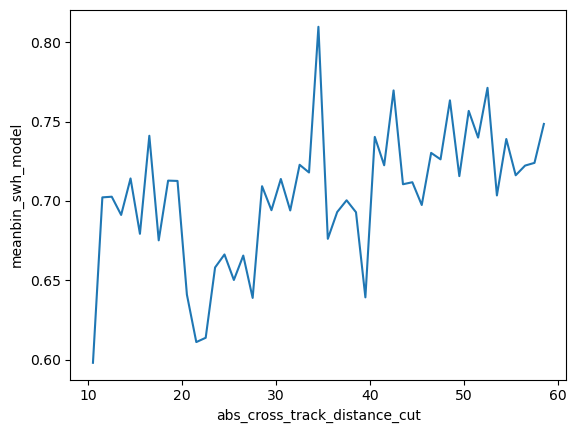

In [10]:
dsc.meanbin_swh_model.plot()

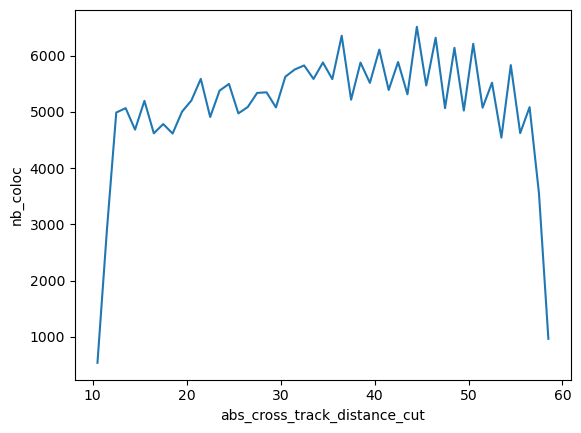

In [11]:
dsc.nb_coloc.plot()

[ 3.54110239e-04 -3.21247455e-02  2.58113672e+00]


Text(0.5, 0, 'Cross - track distance [km]')

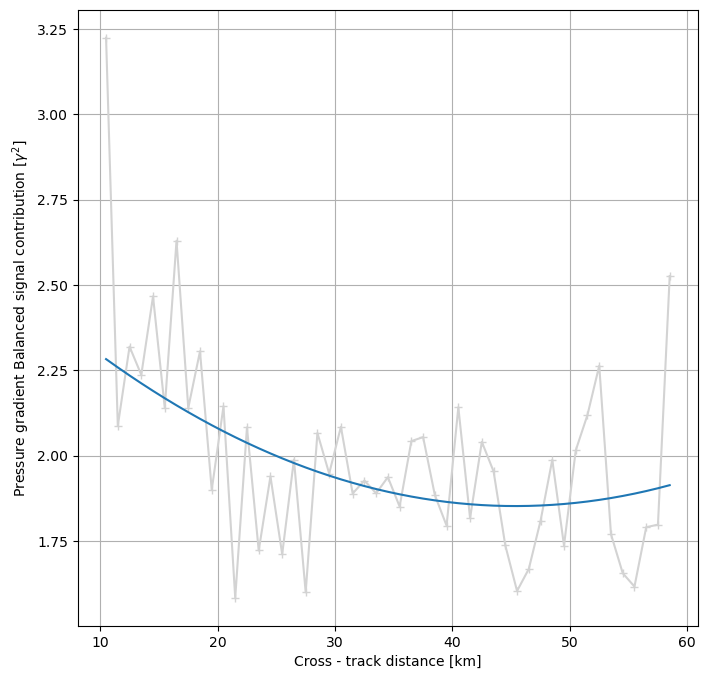

In [18]:
plt.rcParams["axes.edgecolor"] = "k"

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsc['B_ggd'] = dsc.Bx_ggd + dsc.By_ggd

dsc.B_ggd.plot(ax=ax, marker='+', c='lightgrey')

c = dsc.abs_cross_track_distance_cut
coefb = np.polyfit(c, dsc.B_ggd,2,w =dsc.nb_coloc)
ax.plot(c, coefb[0]*c**2  +coefb[1]*c + coefb[2])
print(coefb)


ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')